# Librarys for develop the method

In [4]:
import numpy as np
import pandas as pd
import sympy as sy
import matplotlib.pyplot as plt

# Disparo lineal

C = 1.18630562
y(b) = 2.000000000000, residuo y(b)-beta = 0.000e+00

Muestra de la solución (cada 20 puntos) y punto final:


,x,y1 (disparo1),z (disparo2),y (solución combinada)
1,0.00,1.000000,0.000000,1.000000
2,0.05,0.997565,0.050065,1.056958
3,0.10,0.990522,0.100522,1.109772
4,0.15,0.979255,0.151755,1.159284
5,0.20,0.964139,0.204139,1.206311
6,0.25,0.945530,0.258030,1.251633
7,0.30,0.923760,0.313760,1.295976
8,0.35,0.899133,0.371633,1.340003
9,0.40,0.871915,0.431915,1.384298
10,0.45,0.842332,0.494832,1.429354


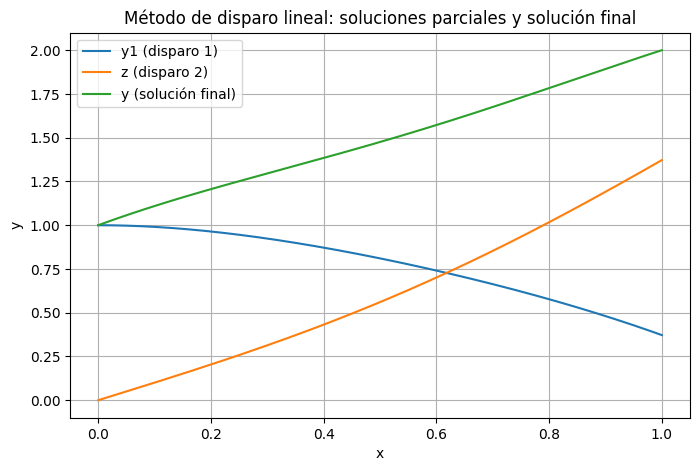

In [ ]:
# Solución numérica por el método de disparo lineal (ejemplo más complejo)
# Ecuación (lineal) en forma estándar:
# y'' + p(x)*y' + q(x)*y = r(x),  a <= x <= b
#
# Elegimos:
# p(x) = -2*x/(1+x^2)
# q(x) = 2/(1+x^2)
# r(x) = sin(pi*x)
# con condiciones frontera: y(0) = 1, y(1) = 2
#
# Implementamos un integrador RK4 clásico para el sistema de primer orden:
# y1 = y, y2 = y'
# y1' = y2
# y2' = -p(x)*y2 - q(x)*y1 + r(x)
#
# Método de disparo lineal:
# - Resolvemos dos IVP:
#   (A) y1 with y(a)=alpha, y'(a)=s1 (e.g., s1=0)
#   (B) z  with z(a)=0, z'(a)=1  (perturbación)
# - Combinamos: y = y1 + C * z, donde C = (beta - y1(b)) / z(b)

import math


# Parámetros del problema

a = float(input("Lower bound: "))
b = float(input("Upper bound: "))
alpha = float(input("Write the alpha value: "))
beta = float(input("Write the beta value: "))

p = eval(f"lambda x:{input("Write p function: ")}")
q = eval(f"lambda x:{input("Write q function: ")}")
r = eval(f"lambda x:{input("Write r function: ")}")

""" a, b = 0.0, 1.0
alpha = 1.0   # y(a)
beta  = 2.0   # y(b) """
n = 400       # número de pasos (malla fina)

# funciones p(x), q(x), r(x)
""" def p(x):
    return -2*x/(1+x**2)

def q(x):
    return 2/(1+x**2)

def r(x):
    return math.sin(math.pi * x) """

# RHS del sistema de primer orden
def f(x, Y):
    # Y = [y, y']
    y, dy = Y
    ddy = -p(x)*dy - q(x)*y + r(x)
    return np.array([dy, ddy], dtype=float)

# RK4 para sistema de 1º orden
def rk4_step(fun, x, Y, h):
    k1 = fun(x, Y)
    k2 = fun(x + 0.5*h, Y + 0.5*h*k1)
    k3 = fun(x + 0.5*h, Y + 0.5*h*k2)
    k4 = fun(x + h, Y + h*k3)
    return Y + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def integrate(fun, Y0, x_grid):
    Y = np.zeros((len(x_grid), len(Y0)), dtype=float)
    Y[0] = Y0
    for i in range(len(x_grid)-1):
        h = x_grid[i+1] - x_grid[i]
        Y[i+1] = rk4_step(fun, x_grid[i], Y[i], h)
    return Y

# malla
x = np.linspace(a, b, n+1)

# Disparo 1: y1 con s1 = 0 (o cualquier s1; elegimos 0)
s1 = 0.0
Y0_1 = np.array([alpha, s1])
Y1 = integrate(f, Y0_1, x)
y1 = Y1[:,0]

# Disparo 2: z con z(a)=0, z'(a)=1 (solución de la ecuación homogénea dirigida por la derivada)
Y0_2 = np.array([0.0, 1.0])
Z = integrate(f, Y0_2, x)
z = Z[:,0]

# Calculamos la constante C usando la condición en b
yb = y1[-1]
zb = z[-1]
if abs(zb) < 1e-14:
    raise RuntimeError("z(b) es demasiado cercano a cero; el método falla o requiere otra elección de IVPs.")

C = (beta - yb) / zb

# Solución combinada
y = y1 + C * z

# Verificamos la condición en b
residuo = y[-1] - beta

# Mostramos resultados: valor de C, residuo, y tabla de muestras
print(f"C = {C:.8f}")
print(f"y(b) = {y[-1]:.12f}, residuo y(b)-beta = {residuo:.3e}")

# Construimos un DataFrame con algunas columnas para inspección
df = pd.DataFrame({
    "x": x,
    "y1 (disparo1)": y1,
    "z (disparo2)": z,
    "y (solución combinada)": y
})

# Mostramos una tabla reducida (cada 20 puntos) y la última fila
display_df = pd.concat([df.iloc[::20].reset_index(drop=True), df.tail(1).reset_index(drop=True)])
display_df.index = range(1, len(display_df)+1)
print("\nMuestra de la solución (cada 20 puntos) y punto final:")
display_df_round = display_df.round(8)
display(display_df_round)

# Gráfica de la solución
plt.figure(figsize=(8,5))
plt.plot(x, y1, label="y1 (disparo 1)")
plt.plot(x, z, label="z (disparo 2)")
plt.plot(x, y, label="y (solución final)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Método de disparo lineal: soluciones parciales y solución final")
plt.legend()
plt.grid(True)
plt.show()
